In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset with encoding fix
df = pd.read_csv(r"C:\Users\Sai Naga Shreehitha\Downloads\boiler.csv", encoding="latin-1")
print(df.columns)

Index(['Unnamed: 0', 'date', 'PT_8313A.AV_0#', 'PT_8313B.AV_0#',
       'PT_8313C.AV_0#', 'PT_8313D.AV_0#', 'PT_8313E.AV_0#', 'PT_8313F.AV_0#',
       'PTCA_8322A.AV_0#', 'PTCA_8324.AV_0#', 'TE_8319A.AV_0#',
       'TE_8319B.AV_0#', 'TE_8313B.AV_0#', 'TE_8303.AV_0#', 'TE_8304.AV_0#',
       'TV_8329ZC.AV_0#', 'FT_8301.AV_0#', 'FT_8302.AV_0#', 'FT_8306A.AV_0#',
       'AIR_8301A.AV_0#', 'FT_8306B.AV_0#', 'AIR_8301B.AV_0#', 'YFJ3_AI.AV_0#',
       'YFJ3_ZD1.AV_0#', 'YFJ3_ZD2.AV_0#', 'SXLTCYZ.AV_0#', 'SXLTCYY.AV_0#',
       'ZCLCCY.AV_0#', 'YCLCCY.AV_0#', 'YJJWSLL.AV_0#', 'ZZQBCHLL.AV_0#',
       'TE_8332A.AV_0#'],
      dtype='object')


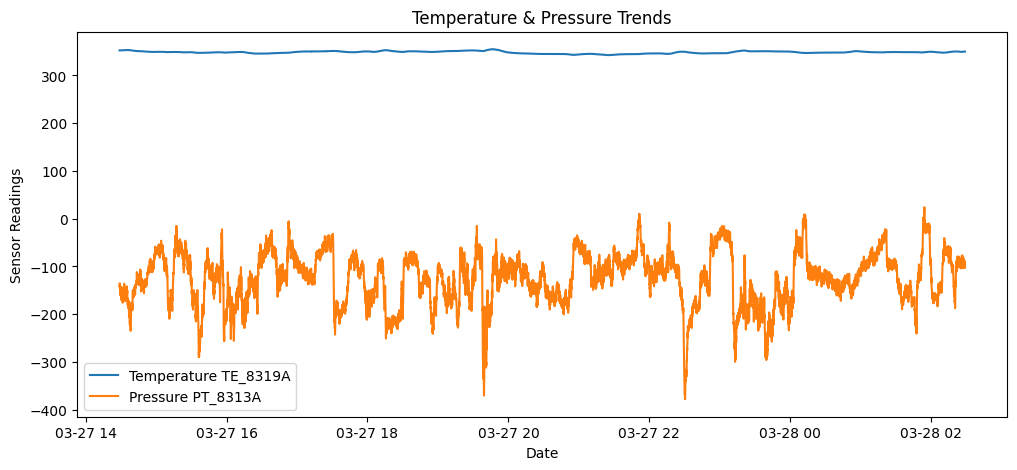

C:\Users\Sai Naga Shreehitha\AppData\Local\Temp\ipykernel_4152\1372878336.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


KeyError: 'FAILURE column not found in dataset'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(r"C:\Users\Sai Naga Shreehitha\Downloads\boiler.csv", encoding="latin-1")
df.columns = df.columns.str.strip().str.upper()
if 'DATE' in df.columns:
    df['DATE'] = pd.to_datetime(df['DATE'])
else:
    raise KeyError("DATE column not found in dataset")
df.drop(columns=['UNNAMED: 0'], inplace=True, errors='ignore')
plt.figure(figsize=(12, 5))
sns.lineplot(x=df['DATE'], y=df['TE_8319A.AV_0#'], label='Temperature TE_8319A')
sns.lineplot(x=df['DATE'], y=df['PT_8313A.AV_0#'], label='Pressure PT_8313A')
plt.xlabel('Date')
plt.ylabel('Sensor Readings')
plt.legend()
plt.title('Temperature & Pressure Trends')
plt.show()

rolling_cols = ['TE_8319A.AV_0#', 'PT_8313A.AV_0#', 'TE_8319B.AV_0#', 'PT_8313B.AV_0#']
for col in rolling_cols:
    if col in df.columns:
        df[f'{col}_AVG'] = df[col].rolling(window=5, min_periods=1).mean()
df.fillna(method='bfill', inplace=True)

features = ['TE_8319A.AV_0#', 'PT_8313A.AV_0#', 'TE_8319A.AV_0#_AVG', 'PT_8313A.AV_0#_AVG']
X = df[features].copy()
y = df['FAILURE'] if 'FAILURE' in df.columns else None  
if y is None:
    raise KeyError("FAILURE column not found in dataset")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', title='Feature Importance', color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()
